# Submissão Final — Comparação e Inferência dos Modelos
Este notebook compara os dois modelos desenvolvidos (NumPy DNN e PyTorch GRU), seleciona os melhores e gera as previsões finais para submissão.

In [3]:
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
import re
import sys
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from src.numpy_text_features import transform_tfidf

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '.')))
os.makedirs("plots", exist_ok=True)

# Registar NeuralNetworkTracked antes do pickle.load (foi guardada com esse nome no notebook 1)
from src.neuralnet import NeuralNetwork
class NeuralNetworkTracked(NeuralNetwork):
    pass
sys.modules["__main__"].NeuralNetworkTracked = NeuralNetworkTracked

# Configuração do Dataset de Teste (
PATH_DATASET_TESTE = "data/val.csv"
df_teste = pd.read_csv(PATH_DATASET_TESTE, sep=",")

# Carregar artefactos NumPy
with open("modelo_numpy_artefactos.pkl", "rb") as f:
    artefactos = pickle.load(f)
le = artefactos["label_encoder"]

print(f"Dataset de teste carregado: {len(df_teste)} exemplos")
print(f"Classes: {le.classes_}")

Dataset de teste carregado: 225 exemplos
Classes: ['Human' 'Google' 'Meta' 'OpenAI' 'Anthropic']


## 1. Comparação das Métricas dos Dois Modelos

In [4]:
# Carregar métricas guardadas dos dois notebooks de treino
numpy_metrics   = artefactos.get("metrics", {})

pytorch_metrics = {}
if os.path.exists("pytorch_metrics.pkl"):
    with open("pytorch_metrics.pkl", "rb") as f:
        pytorch_metrics = pickle.load(f)

metrics_labels = ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1", "Macro Precision", "Macro Recall"]
keys = ["test_accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]

np_vals  = [numpy_metrics.get(k, 0)   for k in keys]
pt_vals  = [pytorch_metrics.get(k, 0) for k in keys]

print("╔══════════════════════════════════════════════════════════════╗")
print("║           COMPARAÇÃO DOS MODELOS — CONJUNTO DE TESTE         ║")
print("╠══════════════════════════════╦════════════════╦══════════════╣")
print("║ Métrica                      ║  NumPy DNN     ║ PyTorch GRU  ║")
print("╠══════════════════════════════╬════════════════╬══════════════╣")
for label, nv, pv in zip(metrics_labels, np_vals, pt_vals):
    winner = "◄" if nv > pv else ("►" if pv > nv else "=")
    print(f"║ {label:<28} ║ {nv:>12.4f}   ║ {pv:>10.4f}   {winner} ║")
print("╚══════════════════════════════╩════════════════╩══════════════╝")

# Identificar o melhor modelo por Macro F1
best_model_name = "NumPy DNN" if np_vals[2] >= pt_vals[2] else "PyTorch GRU"
print(f"\n★ Melhor modelo por Macro F1: {best_model_name}")

╔══════════════════════════════════════════════════════════════╗
║           COMPARAÇÃO DOS MODELOS — CONJUNTO DE TESTE         ║
╠══════════════════════════════╦════════════════╦══════════════╣
║ Métrica                      ║  NumPy DNN     ║ PyTorch GRU  ║
╠══════════════════════════════╬════════════════╬══════════════╣
║ Accuracy                     ║       0.6503   ║     0.8325   ► ║
║ Balanced Accuracy            ║       0.6503   ║     0.8325   ► ║
║ Macro F1                     ║       0.6491   ║     0.8323   ► ║
║ Weighted F1                  ║       0.6491   ║     0.8323   ► ║
║ Macro Precision              ║       0.6522   ║     0.8330   ► ║
║ Macro Recall                 ║       0.6503   ║     0.8325   ► ║
╚══════════════════════════════╩════════════════╩══════════════╝

★ Melhor modelo por Macro F1: PyTorch GRU


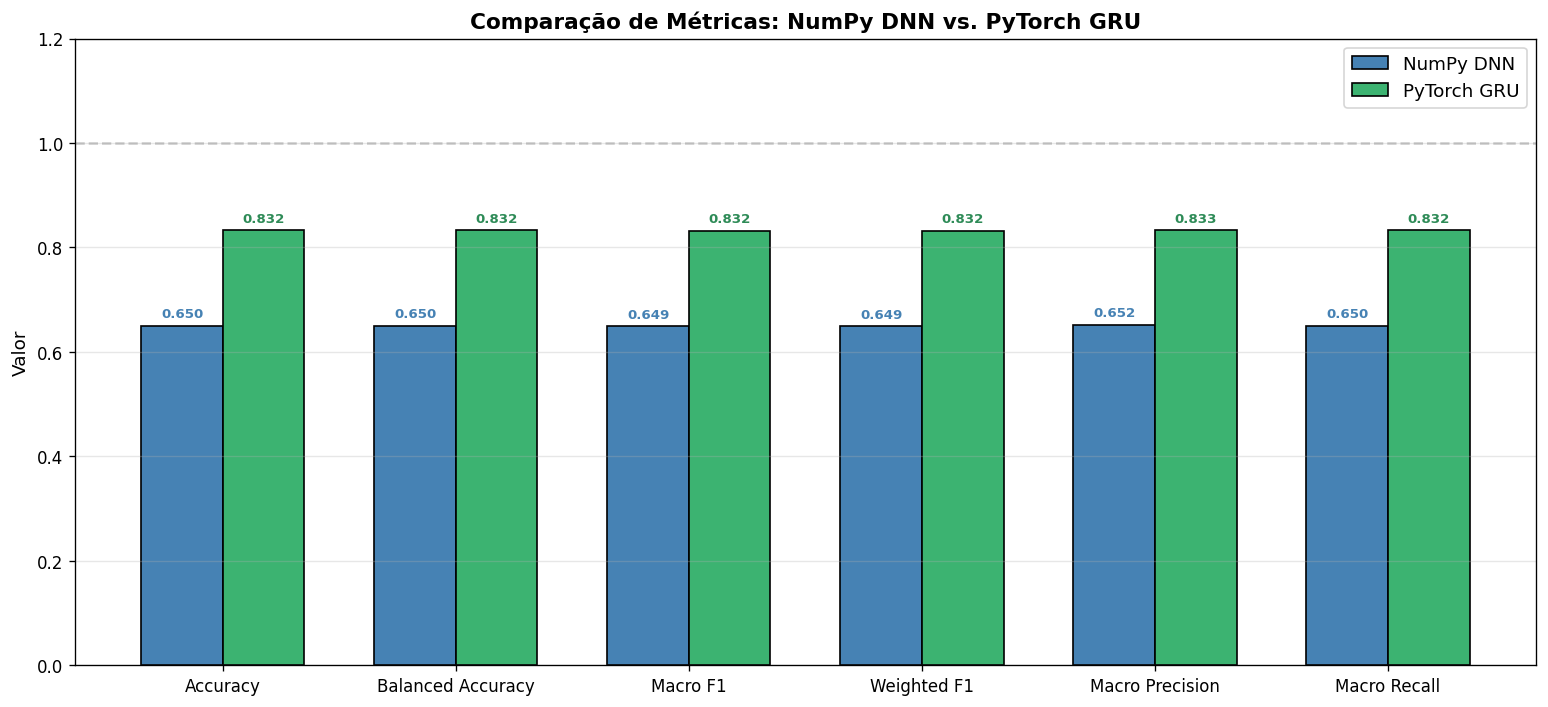

In [5]:
# Gráfico comparativo das métricas
x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, np_vals,  width, label="NumPy DNN",   color='steelblue',    edgecolor='black')
bars2 = ax.bar(x + width/2, pt_vals,  width, label="PyTorch GRU", color='mediumseagreen', edgecolor='black')

for bar, val in zip(bars1, np_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='steelblue')
for bar, val in zip(bars2, pt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylim(0, 1.20)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("Comparação de Métricas: NumPy DNN vs. PyTorch GRU", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/comparacao_modelos.png", bbox_inches='tight')
plt.show()

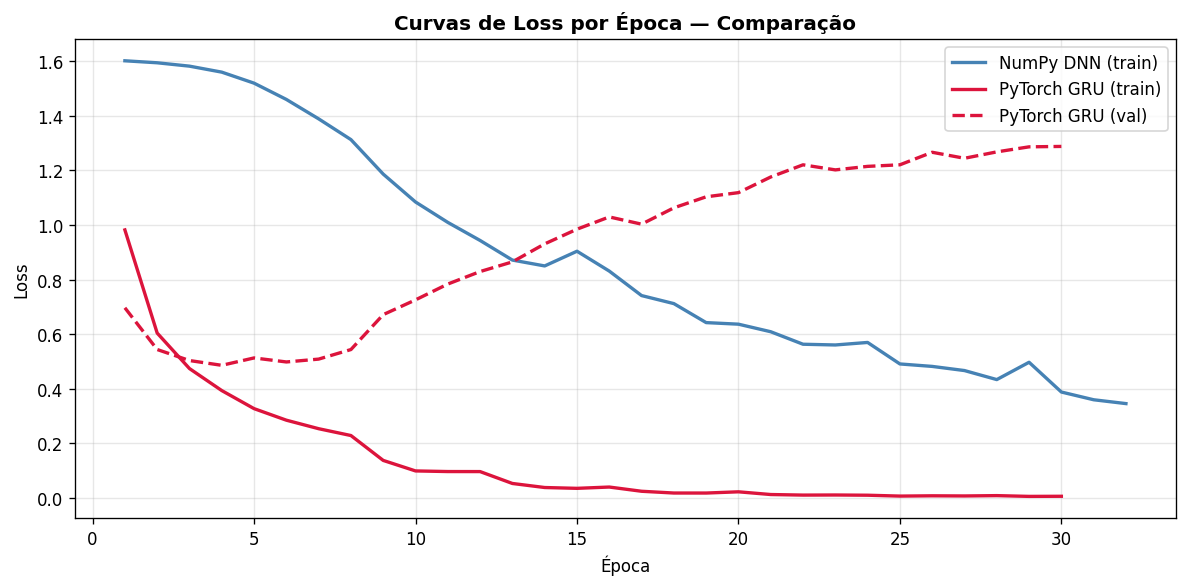

In [6]:
# Curvas de treino sobrepostas (NumPy DNN vs. PyTorch GRU)
np_losses  = numpy_metrics.get("train_losses", [])
pt_history = pytorch_metrics.get("history", {})
pt_losses  = pt_history.get("train_loss", [])
pt_val_losses = pt_history.get("val_loss", [])

if np_losses or pt_losses:
    fig, ax = plt.subplots(figsize=(10, 5))
    if np_losses:
        ax.plot(range(1, len(np_losses)+1), np_losses,
                label="NumPy DNN (train)", color='steelblue', linewidth=2)
    if pt_losses:
        ax.plot(range(1, len(pt_losses)+1), pt_losses,
                label="PyTorch GRU (train)", color='crimson', linewidth=2)
    if pt_val_losses:
        ax.plot(range(1, len(pt_val_losses)+1), pt_val_losses,
                label="PyTorch GRU (val)", color='crimson', linewidth=2, linestyle='--')
    ax.set_title("Curvas de Loss por Época — Comparação", fontsize=12, fontweight='bold')
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/comparacao_curvas_loss.png", bbox_inches='tight')
    plt.show()

## 2. Inferência com o Modelo NumPy DNN

In [7]:
print("-> A executar Inferência com Modelo NumPy DNN...")
vocab = artefactos["vocab"]
idf = artefactos["idf"]
net_np = artefactos["model"]

def clean_text_np(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

texts_clean = df_teste["Text"].apply(clean_text_np).tolist()
X_teste_tfidf = transform_tfidf(texts_clean, vocab, idf)
preds_np_probs = net_np.predict(X_teste_tfidf)
preds_np_idx = np.argmax(preds_np_probs, axis=1)

df_teste["Predict_Numpy_DNN"] = le.inverse_transform(preds_np_idx)
print(f"  Concluído! {len(preds_np_idx)} previsões geradas.")
print("  Distribuição:", pd.Series(df_teste["Predict_Numpy_DNN"]).value_counts().to_dict())

-> A executar Inferência com Modelo NumPy DNN...
  Concluído! 225 previsões geradas.
  Distribuição: {'Google': 98, 'Human': 65, 'OpenAI': 41, 'Meta': 20, 'Anthropic': 1}


## 3. Inferência com o Modelo PyTorch GRU

In [8]:
print("-> A executar Inferência com Modelo PyTorch GRU...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("pytorch_vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.3)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.4)
    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

model_pt = GRUClassifier(len(vocab), 128, 128, len(le.classes_)).to(device)
model_pt.load_state_dict(torch.load("modelo_pytorch_gru.pth", map_location=device))
model_pt.eval()

def encode_pt(text, vocab, max_len=100):
    text   = str(text).lower()
    text   = re.sub(r"<.*?>", "", text)
    tokens = re.sub(r"[^a-z\s]", " ", text).split()
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens][:max_len]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

preds_pt_idx = []
with torch.no_grad():
    for text in df_teste["Text"].values:
        x      = torch.tensor([encode_pt(text, vocab)], dtype=torch.long).to(device)
        output = model_pt(x)
        preds_pt_idx.append(torch.argmax(output, dim=1).item())

df_teste["Predict_PyTorch_GRU"] = le.inverse_transform(preds_pt_idx)
print(f"  Concluído! {len(preds_pt_idx)} previsões geradas.")
print("  Distribuição:", pd.Series(df_teste["Predict_PyTorch_GRU"]).value_counts().to_dict())

-> A executar Inferência com Modelo PyTorch GRU...
  Concluído! 225 previsões geradas.
  Distribuição: {'Anthropic': 112, 'Meta': 108, 'OpenAI': 3, 'Google': 2}


## 4. Análise das Previsões e Concordância entre Modelos

Taxa de concordância entre modelos: 3.11%


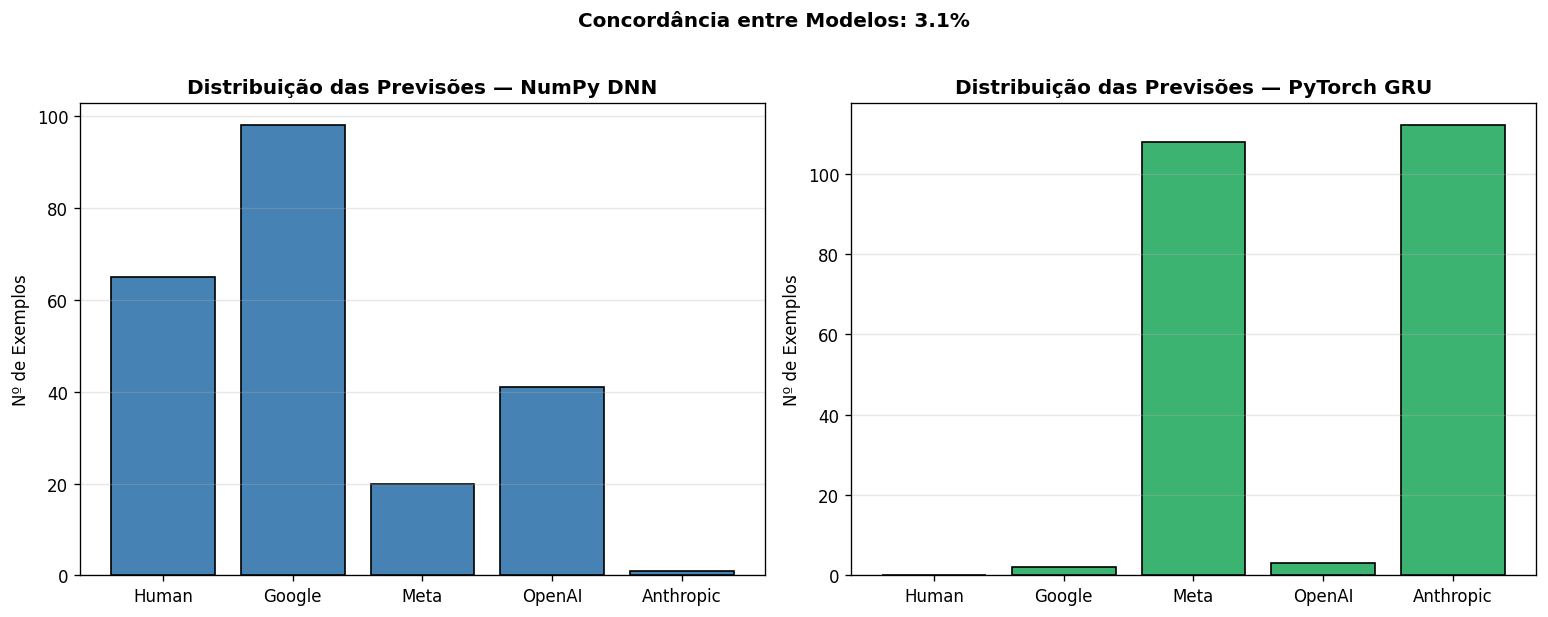

In [9]:
# Concordância entre os dois modelos
df_teste["Concordancia"] = df_teste["Predict_Numpy_DNN"] == df_teste["Predict_PyTorch_GRU"]
taxa_concordancia = df_teste["Concordancia"].mean()
print(f"Taxa de concordância entre modelos: {taxa_concordancia:.2%}")

# Visualizar distribuição das previsões de cada modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

np_counts = df_teste["Predict_Numpy_DNN"].value_counts()
pt_counts = df_teste["Predict_PyTorch_GRU"].value_counts()

# Garantir mesma ordem de classes
all_classes = le.classes_
np_vals_bar = [np_counts.get(c, 0) for c in all_classes]
pt_vals_bar = [pt_counts.get(c, 0) for c in all_classes]

axes[0].bar(all_classes, np_vals_bar, color='steelblue', edgecolor='black')
axes[0].set_title("Distribuição das Previsões — NumPy DNN", fontweight='bold')
axes[0].set_ylabel("Nº de Exemplos")
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(all_classes, pt_vals_bar, color='mediumseagreen', edgecolor='black')
axes[1].set_title("Distribuição das Previsões — PyTorch GRU", fontweight='bold')
axes[1].set_ylabel("Nº de Exemplos")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f"Concordância entre Modelos: {taxa_concordancia:.1%}", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plots/submissao_distribuicao_previsoes.png", bbox_inches='tight')
plt.show()

In [10]:
# Casos onde os modelos discordam 
discordancias = df_teste[~df_teste["Concordancia"]][["ID", "Text", "Predict_Numpy_DNN", "Predict_PyTorch_GRU"]]
print(f"Exemplos com discordância: {len(discordancias)} / {len(df_teste)}")
if len(discordancias) > 0:
    print("\nPrimeiros exemplos de discordância:")
    display(discordancias.head(5))

Exemplos com discordância: 218 / 225

Primeiros exemplos de discordância:


,ID,Text,Predict_Numpy_DNN,Predict_PyTorch_GRU
0,D1-1,"It is an approximation useful in chemistry, bu...",Human,Meta
1,D1-2,"PET scanning, or Positron Emission Tomography,...",OpenAI,Anthropic
2,D1-3,Positron Emission Tomography (PET) scanning is...,Google,Anthropic
3,D1-4,Thermonuclear fusion is the process of combini...,Google,Anthropic
4,D1-5,"These nutrients are needed to keep bones, teet...",Human,Meta


## 5. Guardar Resultado Final para Submissão

In [11]:
NOME_FICHEIRO_SAIDA = "resultados.csv"

# Colunas finais para submissão
cols_saida = ["ID", "Text", "Predict_Numpy_DNN", "Predict_PyTorch_GRU"]
df_saida = df_teste[cols_saida].copy()

df_saida.to_csv(NOME_FICHEIRO_SAIDA, index=False, sep=";")
print(f"Previsões finalizadas e guardadas em '{NOME_FICHEIRO_SAIDA}'!")

display(df_saida.head(10))

Previsões finalizadas e guardadas em 'resultados.csv'!


,ID,Text,Predict_Numpy_DNN,Predict_PyTorch_GRU
0,D1-1,"It is an approximation useful in chemistry, bu...",Human,Meta
1,D1-2,"PET scanning, or Positron Emission Tomography,...",OpenAI,Anthropic
2,D1-3,Positron Emission Tomography (PET) scanning is...,Google,Anthropic
3,D1-4,Thermonuclear fusion is the process of combini...,Google,Anthropic
4,D1-5,"These nutrients are needed to keep bones, teet...",Human,Meta
5,D1-6,"Vitamin D is far more than just a vitamin, it’...",Google,Anthropic
6,D1-7,Vitamin D is essential for maintaining healthy...,Google,Google
7,D1-8,"Vitamin D is essential for human health, with ...",OpenAI,OpenAI
8,D1-9,Thermonuclear fusion is the process powering t...,Google,Anthropic
9,D1-10,"Within 50 million years, the pressure and dens...",Human,Meta


In [12]:
# Resumo final impresso
print("\n" + "=" * 60)
print("   RESUMO FINAL DA SUBMISSÃO")
print("=" * 60)
print(f"  Total de exemplos classificados  : {len(df_saida)}")
print(f"  Taxa de concordância entre modelos: {taxa_concordancia:.2%}")
print()

if numpy_metrics and pytorch_metrics:
    print("  Métricas no dataset de treino/teste interno:")
    print(f"    NumPy DNN  — Macro F1: {numpy_metrics.get('macro_f1',0):.4f} | Accuracy: {numpy_metrics.get('test_accuracy',0):.4f}")
    print(f"    PyTorch GRU— Macro F1: {pytorch_metrics.get('macro_f1',0):.4f} | Accuracy: {pytorch_metrics.get('test_accuracy',0):.4f}")
    print()
    best = "NumPy DNN" if numpy_metrics.get('macro_f1',0) >= pytorch_metrics.get('macro_f1',0) else "PyTorch GRU"
    print(f"  ★ Modelo com maior Macro F1: {best}")
print("=" * 60)



   RESUMO FINAL DA SUBMISSÃO
  Total de exemplos classificados  : 225
  Taxa de concordância entre modelos: 3.11%

  Métricas no dataset de treino/teste interno:
    NumPy DNN  — Macro F1: 0.6491 | Accuracy: 0.6503
    PyTorch GRU— Macro F1: 0.8323 | Accuracy: 0.8325

  ★ Modelo com maior Macro F1: PyTorch GRU
